In [1]:
import os
print(os.listdir('dataset'))

['neutrophil', 'monocyte', 'eosinophil', 'lymphocyte']


/opt/anaconda3/envs/hematovision/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


✅ Libraries Loaded

📁 Files in current directory:
['.zshrc.save', '.config', 'Music', 'creates', '.condarc', '.docker', '.DS_Store', 'nltk_data', '.CFUserTextEncoding', '.xonshrc', '.zshrc', 'dataset', '.local', 'Pictures', '.zprofile', 'Postman', '.claude', '.zsh_history', '.ipython', 'Desktop', 'Library', '.matplotlib', '.lesshst', 'Stuff', 'project', 'PycharmProjects', 'Public', '.idlerc', '.tcshrc', '.venv', '.anaconda', 'Movies', 'Applications', '.Trash', '.ipynb_checkpoints', '.jupyter', '.keras', 'Documents', 'venv', 'train.ipynb', '.claude.json', '.vscode', '.bash_profile', 'Downloads', '.continuum', '.gitconfig', '.bash_history', '.zsh_sessions', '.conda']

📁 Classes inside dataset:
['neutrophil', 'monocyte', 'eosinophil', 'lymphocyte']
Found 1992 images belonging to 4 classes.
Found 496 images belonging to 4 classes.


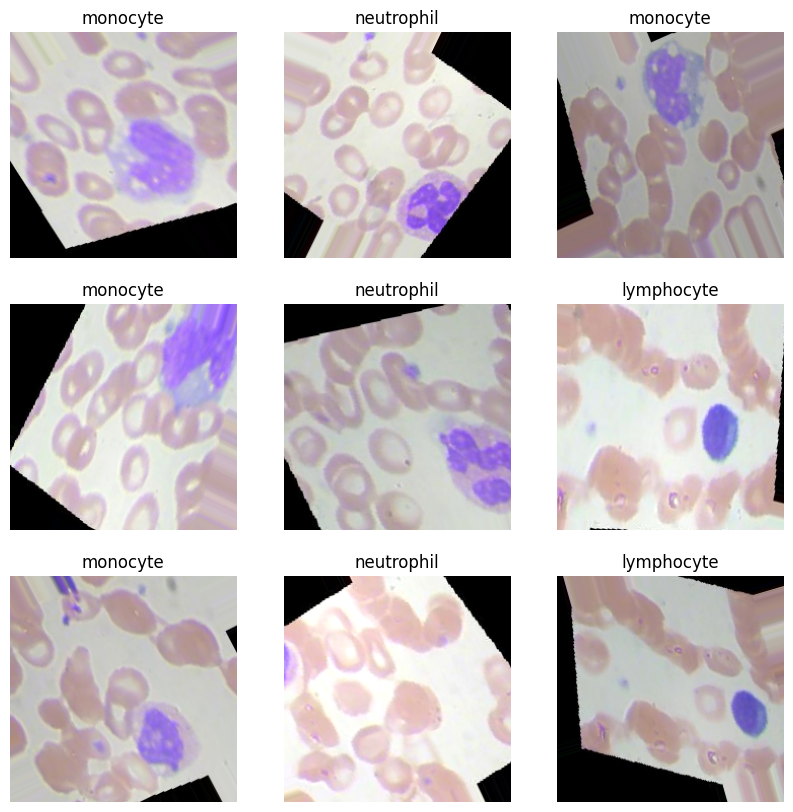


🚀 Starting Training...

Epoch 1/10
63/63 [==============================] - 19s 288ms/step - loss: 1.1165 - accuracy: 0.5321 - val_loss: 0.8197 - val_accuracy: 0.6673
Epoch 2/10
63/63 [==============================] - 18s 288ms/step - loss: 0.6961 - accuracy: 0.7385 - val_loss: 0.7214 - val_accuracy: 0.6976
Epoch 3/10
63/63 [==============================] - 19s 299ms/step - loss: 0.5678 - accuracy: 0.7962 - val_loss: 0.6431 - val_accuracy: 0.7238
Epoch 4/10
63/63 [==============================] - 20s 316ms/step - loss: 0.4857 - accuracy: 0.8273 - val_loss: 0.4306 - val_accuracy: 0.8528
Epoch 5/10
63/63 [==============================] - 22s 350ms/step - loss: 0.4071 - accuracy: 0.8599 - val_loss: 0.4024 - val_accuracy: 0.8508
Epoch 6/10
63/63 [==============================] - 22s 346ms/step - loss: 0.3963 - accuracy: 0.8574 - val_loss: 0.5533 - val_accuracy: 0.7863
Epoch 7/10
63/63 [==============================] - 22s 349ms/step - loss: 0.3558 - accuracy: 0.8695 - val_loss: 0.36

/opt/anaconda3/envs/hematovision/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [2]:
# =============================
# HematoVision - Complete Code
# =============================

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

print("✅ Libraries Loaded")

# =============================
# Check Dataset
# =============================
print("\n📁 Files in current directory:")
print(os.listdir())

print("\n📁 Classes inside dataset:")
print(os.listdir('dataset'))

# =============================
# Data Augmentation
# =============================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    validation_split=0.2
)

# =============================
# Load Dataset
# =============================
train_data = train_datagen.flow_from_directory(
    'dataset/',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    'dataset/',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# =============================
# Visualize Images
# =============================
def show_images(data):
    images, labels = next(data)
    class_names = list(data.class_indices.keys())

    plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        index = np.argmax(labels[i])
        plt.title(class_names[index])
        plt.axis('off')
    plt.show()

show_images(train_data)

# =============================
# Model (Transfer Learning)
# =============================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
output = tf.keras.layers.Dense(4, activation='softmax')(x)

model = tf.keras.models.Model(inputs=base_model.input, outputs=output)

# =============================
# Compile Model
# =============================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🚀 Starting Training...\n")

# =============================
# Train Model
# =============================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# =============================
# Save Model
# =============================
model.save("Blood_Cell.h5")

print("\n✅ Model Saved Successfully as Blood_Cell.h5")